# 1.) Katera država ima najbolj kakovostno življenje?
# 2.) Zakaj ima najboljšo kakovost?

# Priprava podatkov

Na zgornji 2 vprašanji bomo odgovarili na način, da bomo združili več različnih tabel. Ker poskušamo evaluirati aktualno stanje, je potrebno poiskati podatke za najkasnejše razpoložljivo leto, ko bodo na voljo podatki iz vseh treh različnih virov. 

V našem primeru je to leto 2023, ki ga smatramo za dovolj aktualno, da odraža dejansko stanje. Obravnavamo podatke iz naslednjih treh virov:

- World Happiness Report (WHR)
- UNDP Human Development Index (HDI)
- DataBank World Development Indicators (WDI)

Prvi dve tabeli sta zgolj za leto 2023, medtem ko zadnja vsebuje indekse za več kot 60 let.

Podatke bomo združili v eno tabelo, na način, da bomo imeli za vsako državo po eno vrstico, nato pa bodo stolpci predstavljali specifične atribute za to države, za leto 2023.
  

In [138]:
# SETUP

# dependencies:

# jupyter
# pandas
# matplotlib
# scikit-learn
# country_converter
# xlrd
# openpyxl
# seaborn



In [140]:

import pandas as pd
import country_converter as coco


df_happiness = pd.read_excel('data/WHR23_Data_Figure_2.1.xls')
df_hdi = pd.read_excel('data/HDR25_Statistical_Annex_HDI_Table.xlsx')
df_wb = pd.read_excel('data/WDIEXCEL.xlsx')


cc = coco.CountryConverter()

In [141]:
df_hdi.head()

,Unnamed: 0,Table 1. Human Development Index and its components,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,SDG3,NaN,SDG4.3,NaN,SDG4.4,NaN,SDG8.5,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Human Development Index (HDI),NaN,Life expectancy at birth,NaN,Expected years of schooling,NaN,Mean years of schooling,NaN,Gross national income (GNI) per capita,NaN,GNI per capita rank minus HDI rank,NaN,HDI rank
4,HDI rank,Country,Value,NaN,(years),NaN,(years),NaN,(years),NaN,(2021 PPP $),NaN,NaN,NaN,NaN


Uporabimo country_converter, ki nam bo pomagal združiti željene tabele. Modelu uporablja regularne izraze, kar bo poenostavilo kategorizacijo držav
po ISO kodah, po katerih bomo kasneje združevali tabele. Tako v tabeli ustvarimo nov stolpec z imenom `iso_code`.

In [142]:
df_happiness['iso_code'] = cc.convert(names=df_happiness['Country name'], to='ISO3')
df_happiness.head()

,Country name,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,iso_code
0,Finland,7.8042,0.036162,7.875078,7.733322,10.792010,0.968770,71.149994,0.961408,-0.018824,0.181745,1.777825,1.888380,1.584900,0.534574,0.771510,0.126331,0.535299,2.363241,FIN
1,Denmark,7.5864,0.041028,7.666815,7.505985,10.962164,0.954112,71.250145,0.933533,0.134242,0.195814,1.777825,1.949406,1.547875,0.537302,0.734416,0.208459,0.525221,2.083766,DNK
2,Iceland,7.5296,0.048612,7.624879,7.434321,10.895531,0.982533,72.050018,0.936349,0.210987,0.667848,1.777825,1.925508,1.619666,0.559096,0.738164,0.249635,0.187119,2.250382,ISL
3,Israel,7.4729,0.031609,7.534853,7.410946,10.638705,0.943344,72.697205,0.808866,-0.023080,0.708094,1.777825,1.833398,1.520674,0.576730,0.568518,0.124048,0.158292,2.691290,ISR
4,Netherlands,7.4030,0.029294,7.460416,7.345583,10.942279,0.930499,71.550018,0.886875,0.212686,0.378929,1.777825,1.942274,1.488228,0.545473,0.672327,0.250547,0.394062,2.110044,NLD


Potrebno je modificirati tabelo, saj se imena atributov pričnejo v 5. vrstici, z izjemo "Country", ki se začne vrstico kasneje. Pravtako je potrebno pobrisati določene stolpce, kateri ne vsebujejo vrednosti, temveč so v tabeli zato, da lahko hranijo določene zaznamke, ki nam ne koristijo.

In [167]:


df_hdi = pd.read_excel('data/HDR25_Statistical_Annex_HDI_Table.xlsx', header=4)
df_hdi.columns.values[0] = 'HDI rank'
df_hdi.columns.values[1] = 'Country'

# izključitev vmesnih stolpcev brez uporabnih vrednosti
df_hdi.drop(df_hdi.columns[[3, 5, 7, 9, 11, 13]], axis=1, inplace=True) # mogoče nevarno, poganjaj samo enkrat
df_hdi.head()

# izključitev zadnjih x vrstic v datoteki, saj vsebujejo zgolj določene meta podatke
df_hdi.tail(50)

x = 70
df_hdi = df_hdi.iloc[:-x]
df_hdi.tail()



,HDI rank,Country,Human Development Index (HDI),Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita,GNI per capita rank minus HDI rank,HDI rank
199,NaN,Other countries or territories,NaN,NaN,NaN,NaN,NaN,NaN,NaN
200,NaN,Korea (Democratic People's Rep. of),..,73.642,12.202153,..,..,..,..
201,NaN,Monaco,..,86.372,21.687241,..,..,..,..
202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203,NaN,Human development groups,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Enako kot pri WHR, uporabimo country_converter tudi pri HDI

In [168]:
df_hdi['iso_code'] = cc.convert(names=df_hdi['Country'], to='ISO3')
df_hdi.head()

Country not found in regex
nan not found in ISO3
Very high human development not found in regex
High human development not found in regex
Medium human development not found in regex
Low human development not found in regex
Other countries or territories not found in regex
nan not found in ISO3
Human development groups not found in regex


,HDI rank,Country,Human Development Index (HDI),Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita,GNI per capita rank minus HDI rank,HDI rank,iso_code
0,HDI rank,Country,Value,(years),(years),(years),(2021 PPP $),NaN,NaN,not found
1,NaN,NaN,2023,2023,2023,2023,2023,2023,2022,not found
2,NaN,Very high human development,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not found
3,1,Iceland,0.972,82.691,18.85059,13.908926,69116.93736,12,3,ISL
4,2,Norway,0.97,83.308,18.79285,13.117962,112710.0211,0,1,NOR


Pri WDI, ki ima države že označene po ISO kodah, lahko stolpec zgolj preimenujemo.

In [174]:
df_wb.rename(columns={'Country Code': 'iso_code'}, inplace=True)
df_wb.head()

,Country Name,iso_code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.685118,19.205632,19.742772,20.332679,20.862800,21.419621,21.996456,22.541440,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.606712,7.926604,8.309896,8.704591,9.106640,9.480804,9.903209,10.288154,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,39.052626,39.321068,39.649534,39.968299,40.354628,40.723805,41.026351,41.289974,NaN,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258,50.667516,NaN,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.584906,25.375037,26.941984,28.983183,30.909991,32.709837,33.747222,35.240236,NaN,NaN


Pri World Bank WDI tabeli imamo težavo s strukturo podatkov oziroma formatom tabele. Pri WHR, kot tudi pri HDI so podatki strukturirani tako, da je vsaka država ena vrstica, ki ima potem različne atribute znotraj stolpcev te vrstice. 
Pri WDI pa imamo opravka z ogromno tabelo, katera vsebuje podatke za mnogo atributov in vrsto let. To je narejeno na način, da posamezna vrstica obravnava zgolj posamezen atribut določene države, v nadaljnih stolpcih pa nato najdemo vrednosti tega atributo za določena leta.

Ker bomo tabele združevali, je potrebno WDI tabelo pretvoriti v format, da bomo lahko izbrane atribute združevali na enak način, kot združujemo pri prvih dveh.

Ker je WDI tabela dosti preobsežna, bomo iz nje ročno izbrali nekaj atributov, ki bodo predstavljali metrike, ki jih želimo uporabiti. 

In [51]:
# izvoz atributov, v namen pregleda, saj je iz dejanske tabele to precej težavno

# all_indicators = pd.Series(df_wb['Indicator Name'].unique())
# all_indicators.to_csv('indicator_menu.txt', index=False)

In [169]:
indicators = [
    'GDP per capita, PPP (current international $)',
    'Life expectancy at birth, total (years)',
    'Individuals using the Internet (% of population)'
    'School enrollment, primary (% net)'
]

Problem z zadnjim izbranim atributom poskušamo rešiti na način, da odsotnost podatkov iz `2023` nadomestimo s podatki iz leta `2017`, ko so le-ti dostopni.

In [171]:
# NaN problemi, 'School enrollment, primary (% net)'
edu_check = df_wb[df_wb['Indicator Name'] == 'School enrollment, primary (% net)']
print(edu_check[['2016','2017','2018','2019', '2020', '2021', '2022', '2023']].notnull().sum())

2016    172
2017    173
2018    105
2019      4
2020      0
2021      0
2022      0
2023      0
dtype: int64


Izberemo samo 4 atribute, katere bomo uporabili. Tri izmed teh bomo vzeli za leto `2023`, medtem ko bomo indeks o izobraževanju pobrali kar iz leta `2017`, saj v kasnejših letih ni več prisoten. Tako dobimo še našo zadnjo tabelo, katera je zreducirana na zgolj 5 stolpcev ter cca 260 vrstic.

In [179]:
modern_indicators = [
    'GDP per capita, PPP (current international $)',
    'Life expectancy at birth, total (years)',
    'Individuals using the Internet (% of population)'
]

# prvi 3 atributi iz leta 2023
df_modern = df_wb[df_wb['Indicator Name'].isin(modern_indicators)]
pivot_modern = df_modern.pivot(index='iso_code', columns='Indicator Name', values='2023').reset_index()

# atribut iz leta 2017
edu_indicator = ['School enrollment, primary (% net)']
df_edu = df_wb[df_wb['Indicator Name'].isin(edu_indicator)]
pivot_edu = df_edu.pivot(index='iso_code', columns='Indicator Name', values='2017').reset_index()

# WDI skupno
wb_final = pd.merge(pivot_modern, pivot_edu, on='iso_code', how='inner')

wb_final.head(10)

Indicator Name,iso_code,"GDP per capita, PPP (current international $)",Individuals using the Internet (% of population),"Life expectancy at birth, total (years)","School enrollment, primary (% net)"
0,ABW,46574.357420,NaN,76.353000,NaN
1,AFE,4501.601101,27.8000,65.146154,NaN
2,AFG,2201.722907,17.7089,66.035000,NaN
3,AFW,6520.280313,38.5000,58.855722,NaN
4,AGO,9753.600468,44.7581,64.617000,NaN
5,ALB,24822.354309,83.1356,79.602000,95.53947
6,AND,71730.668682,95.4456,84.041000,NaN
7,ARB,18488.741561,NaN,72.444678,83.76548
8,ARE,77955.295176,100.0000,82.909000,95.02753
9,ARG,30221.497689,89.2290,77.395000,99.18400


In [181]:
# df_hdi.drop(df_hdi.columns[[3, 5, 7, 9, 11, 13]], axis=1, inplace=True)
df_hdi.head()

,HDI rank,Country,Human Development Index (HDI),Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita,GNI per capita rank minus HDI rank,HDI rank,iso_code
0,HDI rank,Country,Value,(years),(years),(years),(2021 PPP $),NaN,NaN,not found
1,NaN,NaN,2023,2023,2023,2023,2023,2023,2022,not found
2,NaN,Very high human development,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not found
3,1,Iceland,0.972,82.691,18.85059,13.908926,69116.93736,12,3,ISL
4,2,Norway,0.97,83.308,18.79285,13.117962,112710.0211,0,1,NOR


In [182]:
df_happiness.head()

,Country name,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,iso_code
0,Finland,7.8042,0.036162,7.875078,7.733322,10.792010,0.968770,71.149994,0.961408,-0.018824,0.181745,1.777825,1.888380,1.584900,0.534574,0.771510,0.126331,0.535299,2.363241,FIN
1,Denmark,7.5864,0.041028,7.666815,7.505985,10.962164,0.954112,71.250145,0.933533,0.134242,0.195814,1.777825,1.949406,1.547875,0.537302,0.734416,0.208459,0.525221,2.083766,DNK
2,Iceland,7.5296,0.048612,7.624879,7.434321,10.895531,0.982533,72.050018,0.936349,0.210987,0.667848,1.777825,1.925508,1.619666,0.559096,0.738164,0.249635,0.187119,2.250382,ISL
3,Israel,7.4729,0.031609,7.534853,7.410946,10.638705,0.943344,72.697205,0.808866,-0.023080,0.708094,1.777825,1.833398,1.520674,0.576730,0.568518,0.124048,0.158292,2.691290,ISR
4,Netherlands,7.4030,0.029294,7.460416,7.345583,10.942279,0.930499,71.550018,0.886875,0.212686,0.378929,1.777825,1.942274,1.488228,0.545473,0.672327,0.250547,0.394062,2.110044,NLD


Iz WHR izločimo stolpce `Standard error of ladder score` ter `upperwhisker` in `lowerwhisker`, saj ne bodo imeli vloge pri agregaciji vrednosti. Pravtako izločimo vse `Explained by: ...` stolpce, saj so ti že obstoječa interpretacija surovih podatkov za računanje `Ladder score` indeksa.

Nato lahko združimo vse 3 tabele, iz česar bomo dobili tabelo, ki jo bomo nato procesirali za odgovor na vprašanji.

In [201]:
atributi = [
    'iso_code', 
    'Country name', 
    'Ladder score', 
    'Logged GDP per capita', 
    'Social support', 
    'Healthy life expectancy', 
    'Freedom to make life choices', 
    'Generosity', 
    'Perceptions of corruption',
]

# združimo WHR in HDI
skupno = pd.merge(df_happiness[atributi], 
                  df_hdi, 
                  on='iso_code', 
                  how='left')


# dodamo še WDI
skupno = pd.merge(skupno, wb_final, on='iso_code', how='left')

skupno.head(15)

,iso_code,Country name,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,HDI rank,...,Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita,GNI per capita rank minus HDI rank,HDI rank,"GDP per capita, PPP (current international $)",Individuals using the Internet (% of population),"Life expectancy at birth, total (years)","School enrollment, primary (% net)"
0,FIN,Finland,7.8042,10.792010,0.968770,71.149994,0.961408,-0.018824,0.181745,12,...,81.91,19.494089,12.979625,57067.63693,10,11,63414.993688,93.5139,81.685366,98.62944
1,DNK,Denmark,7.5864,10.962164,0.954112,71.250145,0.933533,0.134242,0.195814,4,...,81.933,18.70401,13.027321,76007.85669,4,4,77892.293261,98.7756,81.853659,98.53748
2,ISL,Iceland,7.5296,10.895531,0.982533,72.050018,0.936349,0.210987,0.667848,1,...,82.691,18.85059,13.908926,69116.93736,12,3,81608.447912,99.8301,82.607317,99.83367
3,ISR,Israel,7.4729,10.638705,0.943344,72.697205,0.808866,-0.023080,0.708094,27,...,82.408,14.93416,13.534595,48050.11176,5,23,55171.231881,87.0384,83.195122,97.01884
4,NLD,Netherlands,7.4030,10.942279,0.930499,71.550018,0.886875,0.212686,0.378929,8,...,82.158,18.58485,12.669947,68344.30826,6,7,81728.690463,97.0068,81.914634,98.64765
5,SWE,Sweden,7.3952,10.882823,0.939249,72.150154,0.947971,0.164789,0.202448,5,...,83.262,18.99147,12.740326,66102.08595,10,4,69226.327276,95.7033,83.309756,99.18177
6,NOR,Norway,7.3155,11.087730,0.943477,71.500023,0.946616,0.140636,0.282745,2,...,83.308,18.79285,13.117962,112710.0211,0,1,103637.516844,99.0000,83.112195,99.88251
7,CHE,Switzerland,7.2401,11.164027,0.920439,72.899956,0.891074,0.026686,0.266348,2,...,83.954,16.66753,13.949121,81948.90177,5,2,95141.596094,97.3444,84.056098,93.19583
8,LUX,Luxembourg,7.2279,11.659949,0.878501,71.675003,0.914938,0.023950,0.344978,25,...,82.229,14.35795,12.589372,85461.24833,-19,22,150508.218887,99.3479,83.358537,95.03083
9,NZL,New Zealand,7.1229,10.661865,0.952398,70.350052,0.886574,0.174828,0.271205,17,...,82.088,19.300051,12.882998,47259.60137,17,17,54697.382252,96.1638,83.004878,99.11677


In [207]:
# izločimo vrstice z NaN vrednostmi

skupno_clean = skupno.dropna().copy()
skupno_clean.head()

,iso_code,Country name,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,HDI rank,...,Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita,GNI per capita rank minus HDI rank,HDI rank,"GDP per capita, PPP (current international $)",Individuals using the Internet (% of population),"Life expectancy at birth, total (years)","School enrollment, primary (% net)"
0,FIN,Finland,7.8042,10.792010,0.968770,71.149994,0.961408,-0.018824,0.181745,12,...,81.91,19.494089,12.979625,57067.63693,10,11,63414.993688,93.5139,81.685366,98.62944
1,DNK,Denmark,7.5864,10.962164,0.954112,71.250145,0.933533,0.134242,0.195814,4,...,81.933,18.70401,13.027321,76007.85669,4,4,77892.293261,98.7756,81.853659,98.53748
2,ISL,Iceland,7.5296,10.895531,0.982533,72.050018,0.936349,0.210987,0.667848,1,...,82.691,18.85059,13.908926,69116.93736,12,3,81608.447912,99.8301,82.607317,99.83367
3,ISR,Israel,7.4729,10.638705,0.943344,72.697205,0.808866,-0.023080,0.708094,27,...,82.408,14.93416,13.534595,48050.11176,5,23,55171.231881,87.0384,83.195122,97.01884
4,NLD,Netherlands,7.4030,10.942279,0.930499,71.550018,0.886875,0.212686,0.378929,8,...,82.158,18.58485,12.669947,68344.30826,6,7,81728.690463,97.0068,81.914634,98.64765


In [208]:
print(skupno_clean.columns.tolist())

['iso_code', 'Country name', 'Ladder score', 'Logged GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'HDI rank', 'Country', 'Human Development Index (HDI) ', 'Life expectancy at birth', 'Expected years of schooling', 'Mean years of schooling', 'Gross national income (GNI) per capita', 'GNI per capita rank minus HDI rank', 'HDI rank', 'GDP per capita, PPP (current international $)', 'Individuals using the Internet (% of population)', 'Life expectancy at birth, total (years)', 'School enrollment, primary (% net)']


V izogib podvajanju atributov iz različnih tabel je potrebno določene atribute še naknadno odstraniti, da jim ne umetno povečujemo "teže", ki jo bodo prispevali pri nadaljni obravnavi. Ti atributi so pridobljeni iz enakih virov podatkov, zato ne prispevajo k večji informiranosti o problematiki.

In [211]:

# HDI rank se je iz nekega razloga podvojil? Združevanje, pred brisanjem odvečnih atributov
df_temp = skupno_clean.loc[:, ~skupno_clean.columns.duplicated()].copy()

# odvečni atributi
redundant_cols = [
    'Country', 
    'Life expectancy at birth', 
    'Life expectancy at birth, total (years)',
    'GDP per capita, PPP (current international $)',
    'Gross national income (GNI) per capita',
    'GNI per capita rank minus HDI rank',
]

df_final = df_temp.drop(columns=redundant_cols).copy()
df_final.head()


print(df_final.columns.tolist())
df_final.head()

['iso_code', 'Country name', 'Ladder score', 'Logged GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'HDI rank', 'Human Development Index (HDI) ', 'Expected years of schooling', 'Mean years of schooling', 'Individuals using the Internet (% of population)', 'School enrollment, primary (% net)']


,iso_code,Country name,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,HDI rank,Human Development Index (HDI),Expected years of schooling,Mean years of schooling,Individuals using the Internet (% of population),"School enrollment, primary (% net)"
0,FIN,Finland,7.8042,10.792010,0.968770,71.149994,0.961408,-0.018824,0.181745,12,0.948,19.494089,12.979625,93.5139,98.62944
1,DNK,Denmark,7.5864,10.962164,0.954112,71.250145,0.933533,0.134242,0.195814,4,0.962,18.70401,13.027321,98.7756,98.53748
2,ISL,Iceland,7.5296,10.895531,0.982533,72.050018,0.936349,0.210987,0.667848,1,0.972,18.85059,13.908926,99.8301,99.83367
3,ISR,Israel,7.4729,10.638705,0.943344,72.697205,0.808866,-0.023080,0.708094,27,0.919,14.93416,13.534595,87.0384,97.01884
4,NLD,Netherlands,7.4030,10.942279,0.930499,71.550018,0.886875,0.212686,0.378929,8,0.955,18.58485,12.669947,97.0068,98.64765


In [213]:
print(df_final.columns.tolist())

['iso_code', 'Country name', 'Ladder score', 'Logged GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'HDI rank', 'Human Development Index (HDI) ', 'Expected years of schooling', 'Mean years of schooling', 'Individuals using the Internet (% of population)', 'School enrollment, primary (% net)']


# Ovrednotenje / agregacija

Sedaj, ko imamo počiščeno tabelo, poskušamo ugotoviti kako države med seboj rangirajo. Za mero uporabimo "borda count". Pri tej meri, podatkov ni potrebno normalizirati, saj bomo za vsak atribut rangirali države po temu atributu. Tako bo za vsak atribut državi dodeljeno mesto (1. do 105. v našem primeru) in ta mesta bodo nato agregirana za končno oceno določene države.  

Borda count se na ta način izogne osamelcem, saj le-ti nimajo dovolj vpliva, da bi znatno spremenili končno oceno države. Borda count zato nekako "diskretizira" podatke, saj zanemari relativno razliko med dvema zaporednima rangiranjema. 

In [214]:
# nabor atributov za ovrednotenje
ranking_columns = [
    'Ladder score', 
    'Logged GDP per capita', 
    'Healthy life expectancy', 
    'Human Development Index (HDI) '
]

# duplikat
df_borda_results = df_final.copy()

# borda ocena za vsak atribut
for col in ranking_columns:
    df_borda_results[f'{col}_Rank'] = df_borda_results[col].rank(ascending=True)

# agregacija rangiranj za končno oceno določene države

rank_cols = [f'{col}_Rank' for col in ranking_columns]
df_borda_results['Final_Borda_Score'] = df_borda_results[rank_cols].sum(axis=1)

# sortiranje in izpis lestvice
final_ranking = df_borda_results.sort_values(by='Final_Borda_Score', ascending=False)

print(final_ranking[['Country name', 'Final_Borda_Score']].head(15))

   Country name  Final_Borda_Score
7   Switzerland              405.5
2       Iceland              398.0
6        Norway              393.5
5        Sweden              390.5
1       Denmark              389.0
4   Netherlands              386.5
24    Singapore              381.5
13      Ireland              379.0
8    Luxembourg              379.0
0       Finland              372.0
15      Germany              370.5
11    Australia              364.0
3        Israel              363.0
12       Canada              360.0
10      Austria              360.0


Sedaj lahko pogledamo še borda count z vsemi atributi v tabeli. Tako lahko vidimo, koliko bo uvrstitev vseh vplivala na razporeditev najboljše uvrščenih držav.

In [218]:
import numpy as np

# poiščemo vse stolpce, ki vsebujejo atribute z numeričnimi vrednostmi, da jih bomo vključili v borda agregacijo
all_numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()

# pri specifičnem atributu, je potrebna obrnjeno rangiranje, za razliko od ostalih, je tukaj manj = bolje
reverse_cols = ['Perceptions of corruption']

print(all_numeric_cols)

['Ladder score', 'Logged GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Individuals using the Internet (% of population)', 'School enrollment, primary (% net)']


In [225]:
df_borda_vsi = df_final.copy()

# vključitev vseh atributov
vsi = []
for col in all_numeric_cols:
    if col in reverse_cols:
        df_borda_vsi[f'rank_{col}'] = df_borda_vsi[col].rank(ascending=False)
    else:
        df_borda_vsi[f'rank_{col}'] = df_borda_vsi[col].rank(ascending=True)
    vsi.append(f'rank_{col}')

df_borda_vsi['Borda_vsi_atributi'] = df_borda_vsi[vsi].sum(axis=1)

comparison = df_borda_vsi.sort_values(by='Borda_vsi_atributi', ascending=False)
print(comparison[['Country name', 'Borda_vsi_atributi']].head(15))

      Country name  Borda_vsi_atributi
6           Norway               879.0
2          Iceland               873.0
5           Sweden               863.0
1          Denmark               859.0
4      Netherlands               838.0
9      New Zealand               816.0
0          Finland               810.0
12          Canada               799.0
11       Australia               790.0
24       Singapore               787.0
7      Switzerland               773.0
18  United Kingdom               764.0
8       Luxembourg               762.0
13         Ireland               758.0
36           Malta               724.0


In [226]:
# reset atributov, da vidimo dejanska rangiranja držav
comparison = comparison.reset_index(drop=True)
comparison.index = comparison.index + 1

print(comparison[['Country name', 'Borda_vsi_atributi']].head(15))

      Country name  Borda_vsi_atributi
1           Norway               879.0
2          Iceland               873.0
3           Sweden               863.0
4          Denmark               859.0
5      Netherlands               838.0
6      New Zealand               816.0
7          Finland               810.0
8           Canada               799.0
9        Australia               790.0
10       Singapore               787.0
11     Switzerland               773.0
12  United Kingdom               764.0
13      Luxembourg               762.0
14         Ireland               758.0
15           Malta               724.0


Vidimo, da države na vrhu ostanejo podobne, vendar je npr prej prvouvrščena Švica sedaj padla kar za 10 mest.  

Sedaj lahko poskušamo dobljene podatke še vizualizirati. Z uporabo Plotly, bomo izrisali zemljevid, kjer bomo nato označili države glede na njihovo končno oceno.  
Ker smo že pri čiščenju podatkov vse atribute asociirali z ustrezno ISO kodo države, bo Plotly asociiral vsako kodo z ustreznim polje (zemljevidom državnih mej).

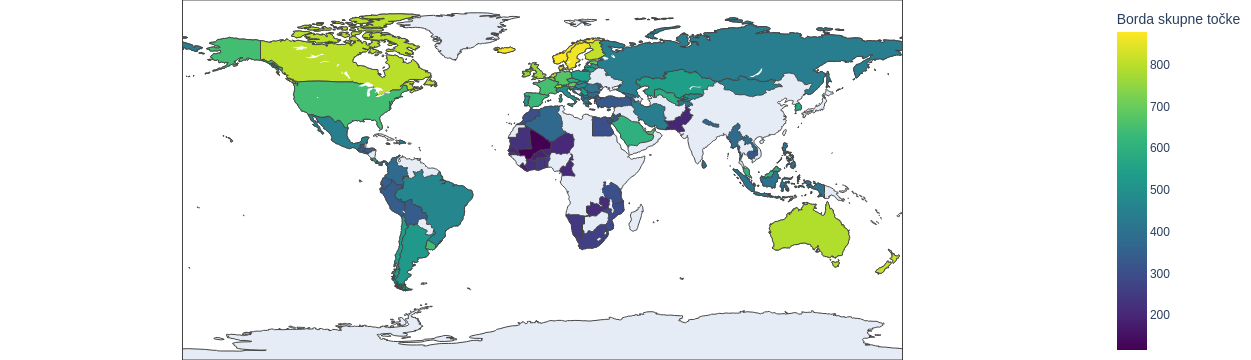

In [256]:
import plotly.express as px

# kreiranje mape
fig = px.choropleth(df_borda_vsi, 
                    locations="iso_code", 
                    color="Borda_vsi_atributi", 
                    hover_name="Country name",
                    hover_data={
                        "Borda_vsi_atributi": True, 
                        "Ladder score": ":.2f", 
                        "Logged GDP per capita": ":.2f",
                        "iso_code": False 
                    },
                    color_continuous_scale=px.colors.sequential.Viridis,
                    labels={'Borda_vsi_atributi': 'Borda skupne točke'})

fig.update_layout(
    margin={"r":0,"t":0,"l":0,"b":0}
)

fig.show()

# Katera država ima najbolj kakovostno življenje?

Odgovor na prvo vprašanje, pri našem naboru atributov, je Norveška.  

Tesno ji sledi Islandija, nato pa še Švedska ter Danska. Takoj se opazi zelo geografsko zgoščen trend najvišjih ocen okoli Skandinavije.

Sedaj pa poglejmo še korelacijsko matriko, iz katere bomo lahko razbrali korelacije med poljubnimi dejavniki pri izračunu. Vizualizirajmo toplotno karto ter se osredotočimo na prvo vrstico. V njej so koeficienti, ki nam povedo, kako posamezni atribut korelira z `Ladder score`. Ta je pri nas indeks, ki opisuje splošno zadovoljstvo / kakovost.

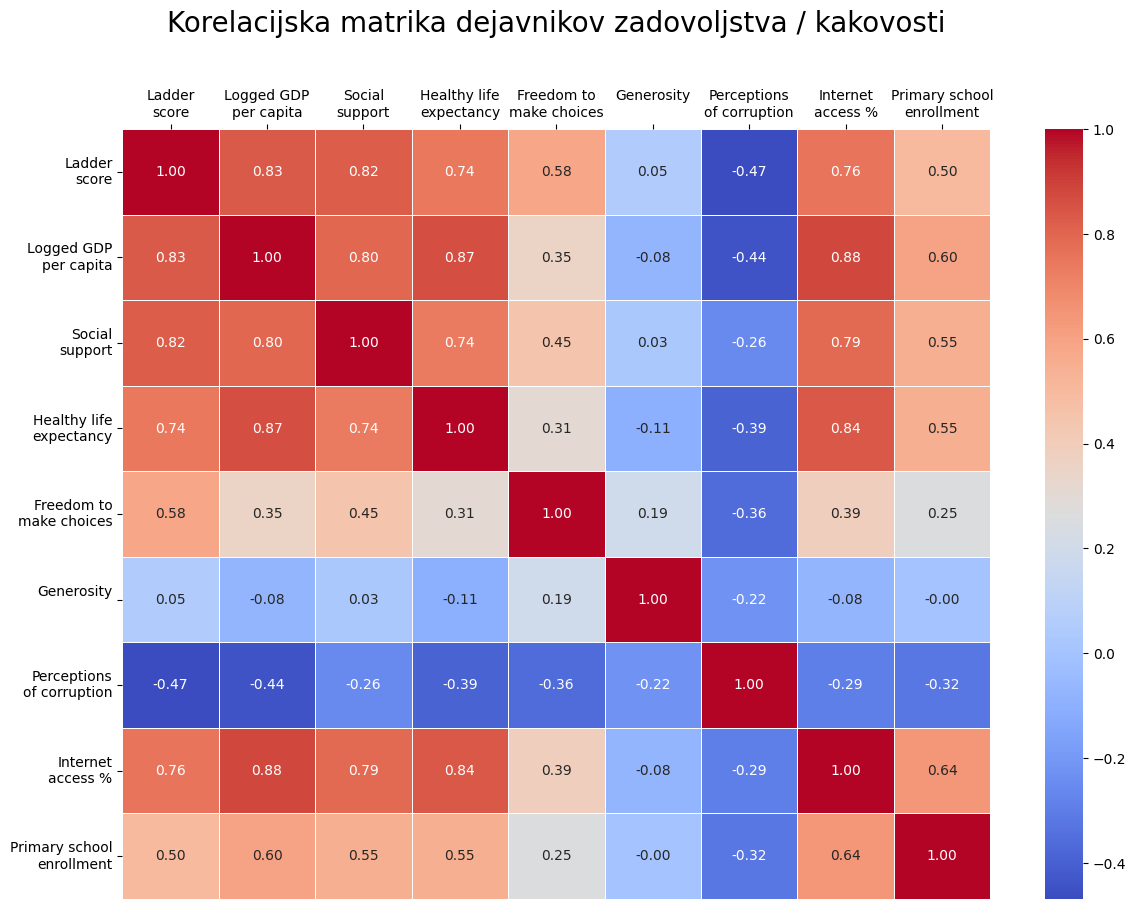

In [306]:
# izberemo vse numerične atribute
vsi_atributi = df_final.select_dtypes(include=['number']).columns.tolist()
# print(vsi_atributi)

# za X-os bomo imena atributov razbili na več vrstic, da jih bomo lahko prikazali brez rotacije
oznake_newline = [
    'Ladder\nscore', 
    'Logged GDP\nper capita', 
    'Social\nsupport', 
    'Healthy life\nexpectancy', 
    'Freedom to\nmake choices', 
    'Generosity\n', 
    'Perceptions\nof corruption', 
    'Internet\naccess %', 
    'Primary school\nenrollment'
]

# izračunamo korelacijsko matriko
corr_matrix = df_final[vsi_atributi].corr()

# izris toplotne karte
plt.figure(figsize=(14, 10))
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# namesto običajnega mesta spodaj, prikažemo atribute zgoraj, saj je 1. vrstica matrike tista z največ pomena. Na ta način je branje matrike preprosteje
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

ax.set_xticklabels(oznake_newline, rotation=0, ha='center')
ax.set_yticklabels(oznake_newline, rotation=0)

plt.xticks(rotation=0, ha='center')
plt.title("Korelacijska matrika dejavnikov zadovoljstva / kakovosti", pad=70, fontsize=20) 

plt.show()

Zgornja matrika jasno pokaže, kateri dejavniki močneje korelirajo z `Ladder score` indeksom.  

Vidimo da imata tako GDP, kot socialna varnost največji vpliv na kakovost življenja posameznika. Nato sledita pričakovana življenjska doba brez hujših zdravstvenih zapletov in dostop do interneta. Nadaljno, so po korelaciji z indeksom blizu svoboda, percepcija korupcije (ta ima negativno korelacijo, ker je skala negirana, v bistvu bi vrednosti morale biti pozitivne)ter opravljanje osnovne šole v populaciji. Na koncu vidimo, da radodarnost zanemarljivo vpliva na naš indeks.  

Na podlagi teh vrednosti, lahko rečemo, da imata tako BDP, kot socialna varnost največji vpliv.

# Zakaj ima najboljšo kakovost?

Za odgovor bomo pogledali, kako se Norveška primerja s povprečno državo na seznamu top10 držav. 

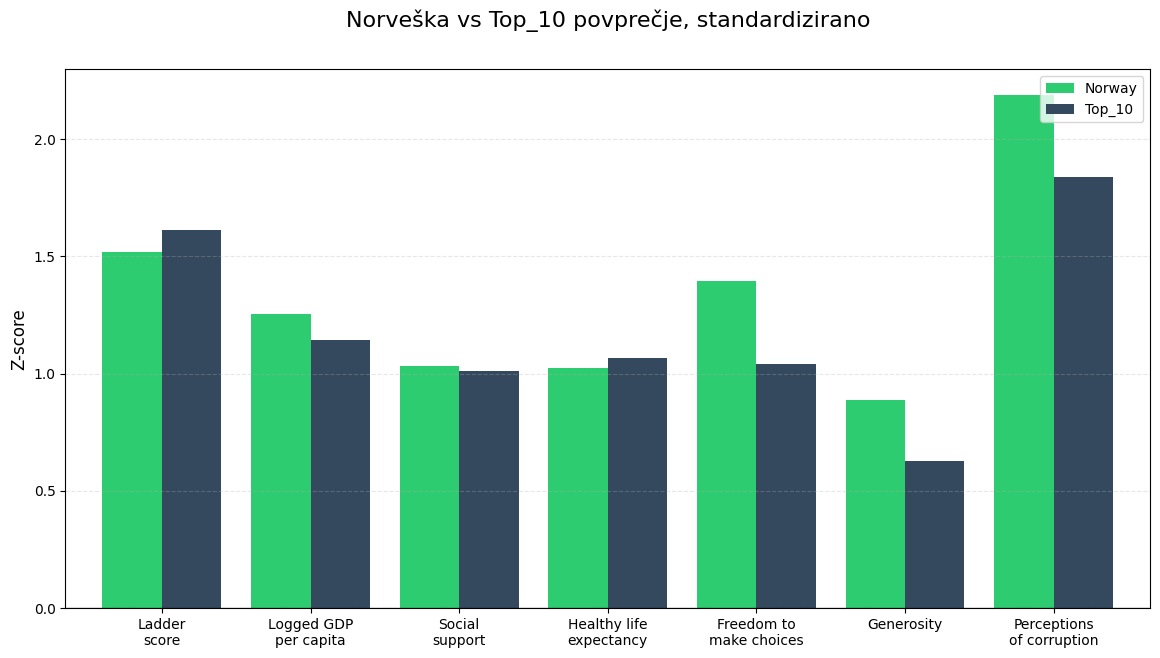

In [320]:
# atributi, ki jih bomo upoštevali, sputimo osnovno šolo / internet, saj sta pri primerjavi najvišje uvrščenih držav nepomembna
factors = [
    'Ladder score', 'Logged GDP per capita', 'Social support', 
    'Healthy life expectancy', 'Freedom to make life choices', 
    'Generosity', 'Perceptions of corruption'
]

# izračun z-vrednosti, na ta način normaliziramo različne numerične intervale za neposredno primerjavo
df_std = df_final[factors].apply(lambda x: (x - x.mean()) / x.std())
df_std['Country name'] = df_final['Country name']

# pri korupciji je potrebna negacija za pravilne vrednosti
df_std['Perceptions of corruption'] = df_std['Perceptions of corruption'] * -1

# seznam top10 držav
top_10_names = df_borda_vsi.head(10)['Country name'].tolist()

# izračunamo vrednosti za oba primera
norway_stats = df_std[df_std['Country name'] == 'Norway'][factors].iloc[0]
top10_avg = df_std[df_std['Country name'].isin(top_10_names)][factors].mean()

# tabela
comparison_df = pd.DataFrame({
    'Norway': norway_stats,
    'Top_10': top10_avg
})

comparison_df.index = oznake_newline

ax = comparison_df.plot(kind='bar', figsize=(14, 7), color=['#2ecc71', '#34495e'], width=0.8)

plt.title("Norveška vs Top_10 povprečje, standardizirano", fontsize=16, pad=30)
plt.ylabel("Z-score", fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

Pri vizualizaciji vidimo, kako Norveška ter povprečna top10 država (elita) diferencirata z globalnim povprečjem. Z-score nam pove, koliko standardnih odklonov je vrednost specifičnega atributa nad vrednostjo globalnega povprečja. 

Vidimo, da ima Norveška sicer npr nižji `Ladder score` napram top_10 povprečju, vendar pa ima znatno višjo svobodo (z-score ~ 2.2, kar jo uvrsti v cca top 1% med vsemi), radodarnost ter boljšo (nižjo) percepcijo korupcije.  
Kombinacija teh treh faktorjev, v kombinaciji z nekoliko višjim BDP od top10 povprečja na koncu rezultira v to, da Norveška zasede 1. mesto med vsemi. 